# TP 1 - Séance 2
## Rehaussement d'image

Équipe #15
- Guindon, Théo (2255253)
- Bererd, Pierre-Louis (2552949)

<span style='color: red;'>
Si la prochaine cellule ne s'exécute pas, c'est qu'il vous manque probablement l'installation de certains packages. Assurez-vous que vous avez dans votre environnement conda les packages listés ici. 
    
Vous pouvez vérifier toutes les installations depuis un terminal Anaconda en activant votre environnement (`conda activate gbm8770`) puis en tapant la commande `conda list` ou `pip list`. 

Si vous ne voyez pas les packages dans la liste ainsi obtenue, vous pouvez les installer avec la commande `pip install package`, en remplaçant le nom du package par celui désiré. 

Attention : le package skimage s'appelle `scikit-image`, il faut donc l'installer avec `pip install scikit-image`. On l'importe ensuite tel qu'écrit dans la prochaine cellule (```import skimage```).

Vous aurez aussi à installer le package `openpyxl` pour vous permettre de charger des fichiers Excel.
</span>

In [2]:
# Importe les modules qui seront utilisés dans le laboratoire.
import numpy as np
from IPython.display import clear_output
import matplotlib.pyplot as plt
from matplotlib.pyplot import imread
from scipy.ndimage import convolve
import skimage.filters as skfilters
import skimage.morphology as skmorph

from cv2 import cvtColor, COLOR_RGB2GRAY
from cv2 import imread as cv2Imread

import os
import pandas as pd
import skimage.draw as drw

%matplotlib inline
# Étend la taille des figures
plt.rcParams["figure.figsize"] = (12, 7)

# Exercice III: Prétraitement d'images grayscale

<font color='red'> Dans toutes les questions de cet exercice, prenez soin de spécifier les bornes des intensités lors de l'affichage. Voir énoncé en pdf. \
Tous les fichiers et les images dont vous aurez besoin pour cette séance sont dans le dossier 'fichiers_seance_2'. Vos chemins devront être ajustés en conséquence. 
</font>

## Égalisation d'histogramme

**1.** Ouvrez, convertissez en valeurs entières et affichez l'image ```radio_thoracique.png```.
Prenez soin de spécifier les bornes des intensités lors de l'affichage.

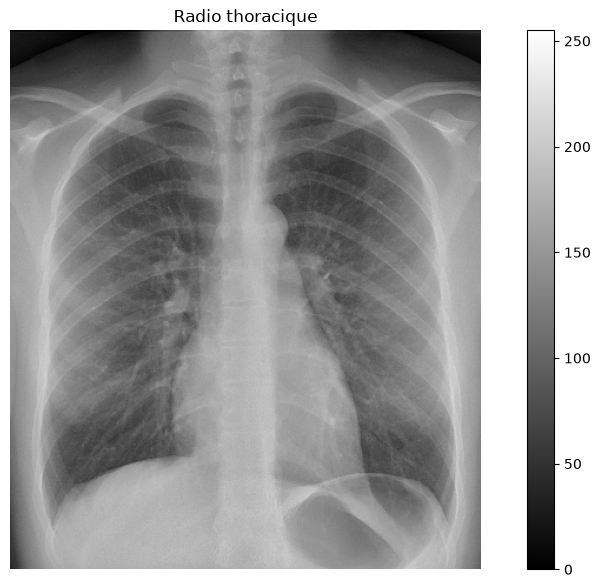

Type: uint8, Min: 0, Max: 214, Shape: (458, 400)


In [3]:
img_radio = imread(os.path.join('fichiers_seance_2', 'radio_thoracique.png'))

# convertir en valeur entiere
if img_radio.max() <= 1.0:
    img_radio = (img_radio * 255).astype(np.uint8)
else:
    img_radio = img_radio.astype(np.uint8)

plt.figure()
plt.imshow(img_radio, cmap='gray', vmin=0, vmax=255)
plt.title('Radio thoracique')
plt.colorbar()
plt.axis('off')
plt.show()

print(f'Type: {img_radio.dtype}, Min: {img_radio.min()}, Max: {img_radio.max()}, Shape: {img_radio.shape}')


**2.** À l'aide de [np.histogram](https://numpy.org/doc/stable/reference/generated/numpy.histogram.html), calculez puis affichez son histogramme.  
Pour gagner du temps aux questions suivantes, vous pouvez définir une fonction qui effectue ces deux opérations.

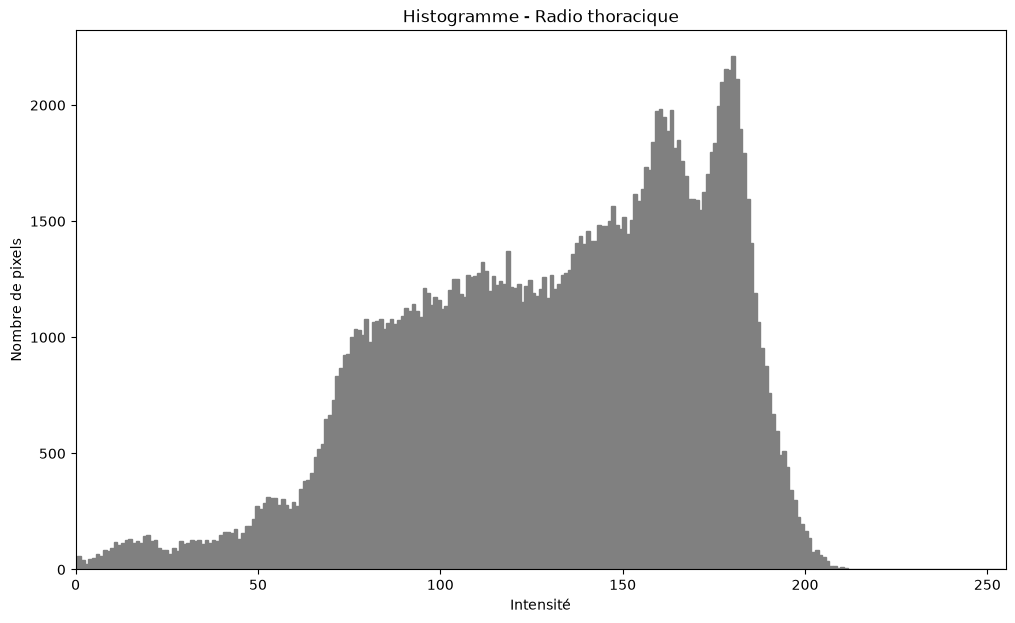

In [4]:
def afficher_histogramme(img, titre='Histogramme', nb_bins=256):
    hist, bin_edges = np.histogram(img.flatten(), bins=nb_bins, range=(0, 255))
    plt.figure()
    plt.bar(bin_edges[:-1], hist, width=1, color='gray', edgecolor='gray')
    plt.title(titre)
    plt.xlabel('Intensité')
    plt.ylabel('Nombre de pixels')
    plt.xlim([0, 255])
    plt.show()
    return hist, bin_edges

hist_radio, bins_radio = afficher_histogramme(img_radio, titre='Histogramme - Radio thoracique')


**3a.** Complétez la fonction ```equalize_histogram(img)``` qui effectue l'égalisation d'histogramme d'une image `img` et renvoie l'image égalisée.

In [ ]:
def equalize_histogram(img):

    L = 256
    hist, _ = np.histogram(img.flatten(), bins=L, range=(0, L-1))
    cdf = hist.cumsum()
    
    # normaliser la CDF pour obtenir le mapping T
    # T(k) = round((L-1) * CDF(k) / N) ou N est le nombre de pixels
    N = img.size
    T = np.round((L - 1) * cdf / N).astype(np.uint8)
    
    img_eq = T[img]
    return img_eq


**3b.** Comparez l'image et son histogramme avant et après l'égalisation. Prenez soin de spécifier les bornes des intensités lors de l'affichage. Que constatez vous? Quel impact a l'égalisation sur le contraste de l'image?

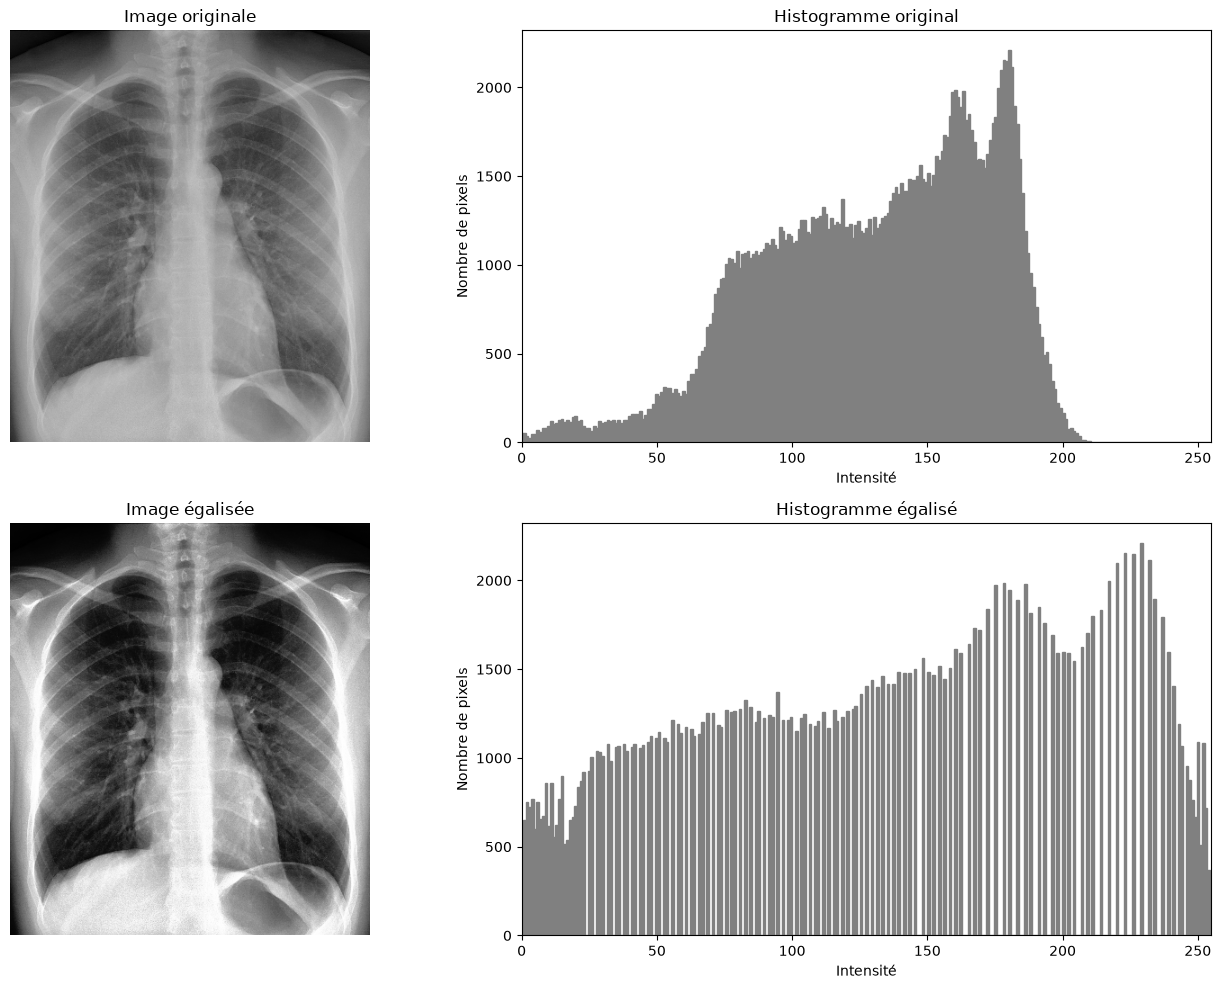

Observation :
L'égalisation d'histogramme redistribue les niveaux de gris de manière plus uniforme.
L'histogramme égalisé est plus étalé sur toute la plage [0, 255].
L'égalisation améliore aussi le contraste global de l'image
en utilisant toute la plage dynamique disponible, rendant les détails plus visibles.


In [6]:
img_radio_eq = equalize_histogram(img_radio)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# image originale
axes[0, 0].imshow(img_radio, cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_title('Image originale')
axes[0, 0].axis('off')

# histogramme original
hist_orig, bin_edges = np.histogram(img_radio.flatten(), bins=256, range=(0, 255))
axes[0, 1].bar(bin_edges[:-1], hist_orig, width=1, color='gray', edgecolor='gray')
axes[0, 1].set_title('Histogramme original')
axes[0, 1].set_xlabel('Intensité')
axes[0, 1].set_ylabel('Nombre de pixels')
axes[0, 1].set_xlim([0, 255])

# image égalisée
axes[1, 0].imshow(img_radio_eq, cmap='gray', vmin=0, vmax=255)
axes[1, 0].set_title('Image égalisée')
axes[1, 0].axis('off')

# histogramme égalisé
hist_eq, bin_edges_eq = np.histogram(img_radio_eq.flatten(), bins=256, range=(0, 255))
axes[1, 1].bar(bin_edges_eq[:-1], hist_eq, width=1, color='gray', edgecolor='gray')
axes[1, 1].set_title('Histogramme égalisé')
axes[1, 1].set_xlabel('Intensité')
axes[1, 1].set_ylabel('Nombre de pixels')
axes[1, 1].set_xlim([0, 255])

plt.tight_layout()
plt.show()

print("Observation :")
print("L'égalisation d'histogramme redistribue les niveaux de gris de manière plus uniforme.")
print("L'histogramme égalisé est plus étalé sur toute la plage [0, 255].")
print("L'égalisation améliore aussi le contraste global de l'image")
print("en utilisant toute la plage dynamique disponible, rendant les détails plus visibles.")


**4.** Effectuez les mêmes opérations qu'à la question **3b** (égalisation d'histogramme puis affichage de l'image et l'histograme avant et après l'égalisation) sur l'image `fundus_mauvais_contraste`. Que constatez-vous ? Que proposeriez-vous afin d'améliorer le contraste et la visibilité des structures de l'oeil dans cette image ?

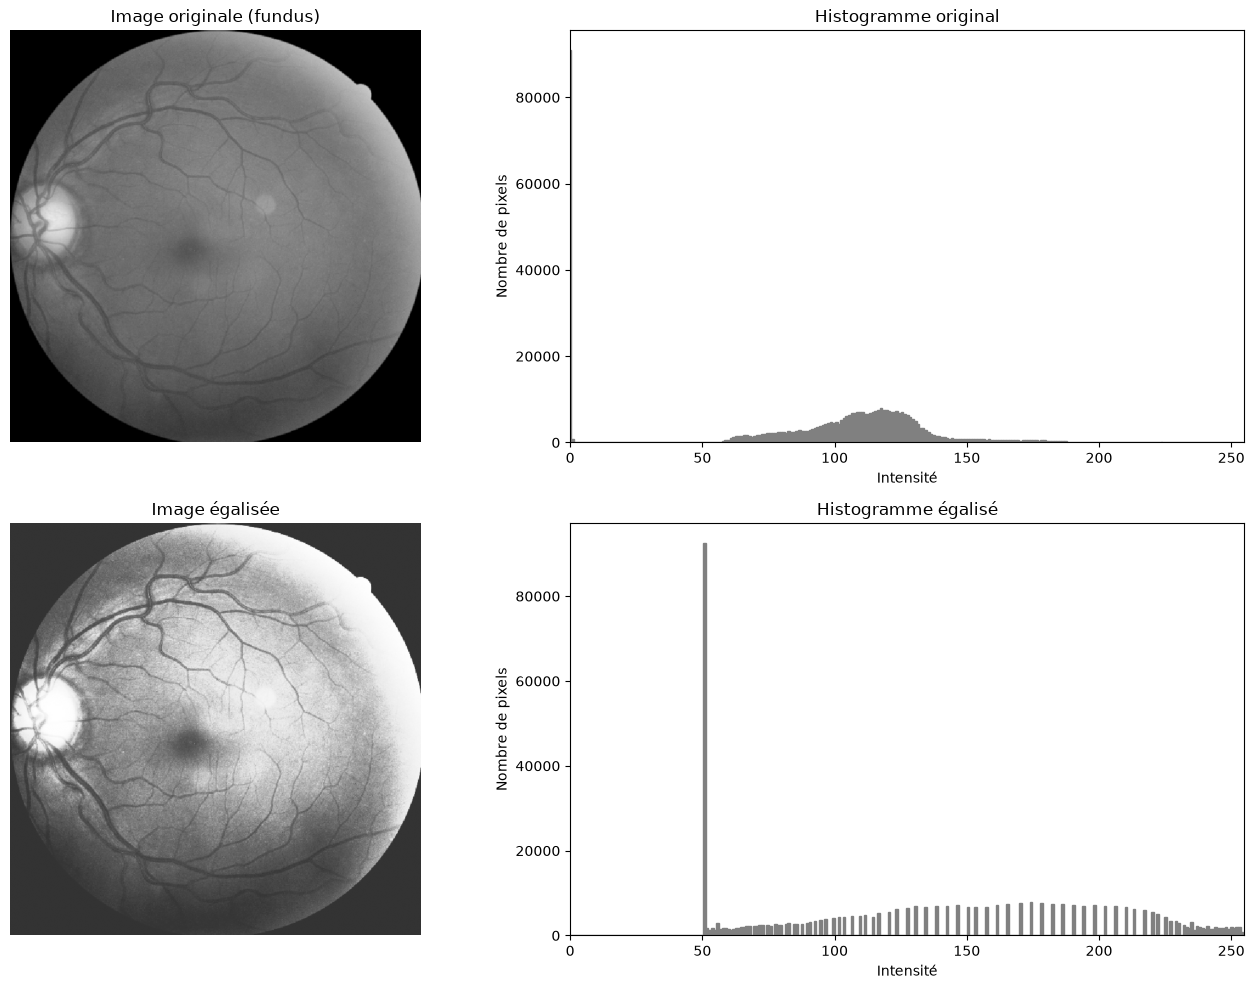

Observation :
L'histogramme original est très concentré dans une plage étroite de valeurs (faible contraste).
Après l'égalisation, l'histogramme est mieux réparti sur la plage [0, 255], ça améliore le contraste global.
Cependant, l'égalisation globale peut amplifier le bruit et ne pas bien fonctionner
sur des images où le contraste varie localement (comme les images de fond d'oeil).
Pour améliorer le résultat, on pourrait utiliser une égalisation adaptative (CLAHE)
qui effectue l'égalisation sur des sous-régions de l'image, préservant mieux les détails locaux.


In [12]:
image = cv2Imread(os.path.join("fichiers_seance_2", "fundus_mauvais_contraste.png"))
gray = cvtColor(image, COLOR_RGB2GRAY)

# égalisation d'histogramme
gray_eq = equalize_histogram(gray)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# image originale
axes[0, 0].imshow(gray, cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_title('Image originale (fundus)')
axes[0, 0].axis('off')

# histogramme original
hist_orig, bin_edges = np.histogram(gray.flatten(), bins=256, range=(0, 255))
axes[0, 1].bar(bin_edges[:-1], hist_orig, width=1, color='gray', edgecolor='gray')
axes[0, 1].set_title('Histogramme original')
axes[0, 1].set_xlabel('Intensité')
axes[0, 1].set_ylabel('Nombre de pixels')
axes[0, 1].set_xlim([0, 255])

# image égalisée
axes[1, 0].imshow(gray_eq, cmap='gray', vmin=0, vmax=255)
axes[1, 0].set_title('Image égalisée')
axes[1, 0].axis('off')

# histogramme égalisé
hist_eq, bin_edges_eq = np.histogram(gray_eq.flatten(), bins=256, range=(0, 255))
axes[1, 1].bar(bin_edges_eq[:-1], hist_eq, width=1, color='gray', edgecolor='gray')
axes[1, 1].set_title('Histogramme égalisé')
axes[1, 1].set_xlabel('Intensité')
axes[1, 1].set_ylabel('Nombre de pixels')
axes[1, 1].set_xlim([0, 255])

plt.tight_layout()
plt.show()

print("Observation :")
print("L'histogramme original est très concentré dans une plage étroite de valeurs (faible contraste).")
print("Après l'égalisation, l'histogramme est mieux réparti sur la plage [0, 255], ça améliore le contraste global.")
print("Cependant, l'égalisation globale peut amplifier le bruit et ne pas bien fonctionner")
print("sur des images où le contraste varie localement (comme les images de fond d'oeil).")
print("Pour améliorer le résultat, on pourrait utiliser une égalisation adaptative (CLAHE)")
print("qui effectue l'égalisation sur des sous-régions de l'image, préservant mieux les détails locaux.")

## Filtrage High-Boost

**5.** Ouvrez l'image ```angiography.jpg```. Convertissez l'image en valeurs flottantes (normalisez par la valeur maximale) et conservez uniquement le premier canal de cette image. Affichez l'image résultante. 

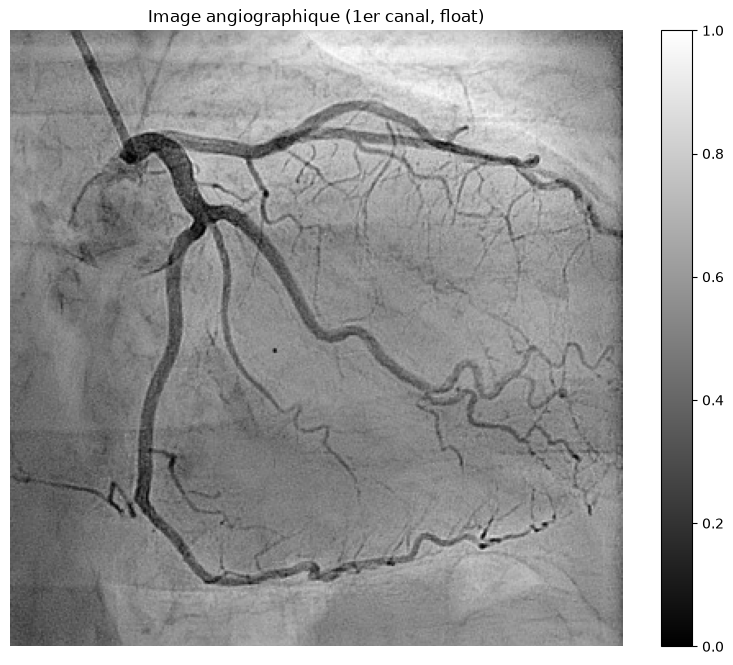

Type: float64, Min: 0.0000, Max: 1.0000, Shape: (376, 374)


In [ ]:
img_angio = imread(os.path.join("fichiers_seance_2", "angiography.jpg"))

# convertir en floats
img_angio = img_angio.astype(np.float64) / img_angio.max()

# conserver uniquement le premier canal
if img_angio.ndim == 3:
    img_angio = img_angio[:, :, 0]

plt.figure(figsize=(10, 8))
plt.imshow(img_angio, cmap='gray', vmin=0, vmax=1)
plt.title('Image angiographique (1er canal, float)')
plt.colorbar()
plt.axis('off')
plt.show()

print(f'Type: {img_angio.dtype}, Min: {img_angio.min():.4f}, Max: {img_angio.max():.4f}, Shape: {img_angio.shape}')

**6.** En utilisant la fonction [convolve](https://docs.scipy.org/doc/scipy/reference/generated/scipy.ndimage.convolve.html), calculez la convolution de l'image angiographique avec une filtre gaussien de taille $3 \times 3$: 

$W_{Gaussienne3}\ =\ \dfrac{1}{16}\ \begin{bmatrix} 1 & 2 & 1 \\ 2 & 4 & 2 \\ 1 & 2 & 1 \end{bmatrix} $

Affichez côte à côte l'image angiographique et le résultat de la convolution.

_N'hésitez pas à augmenter la taille de la figure pour mieux observer les images.)_

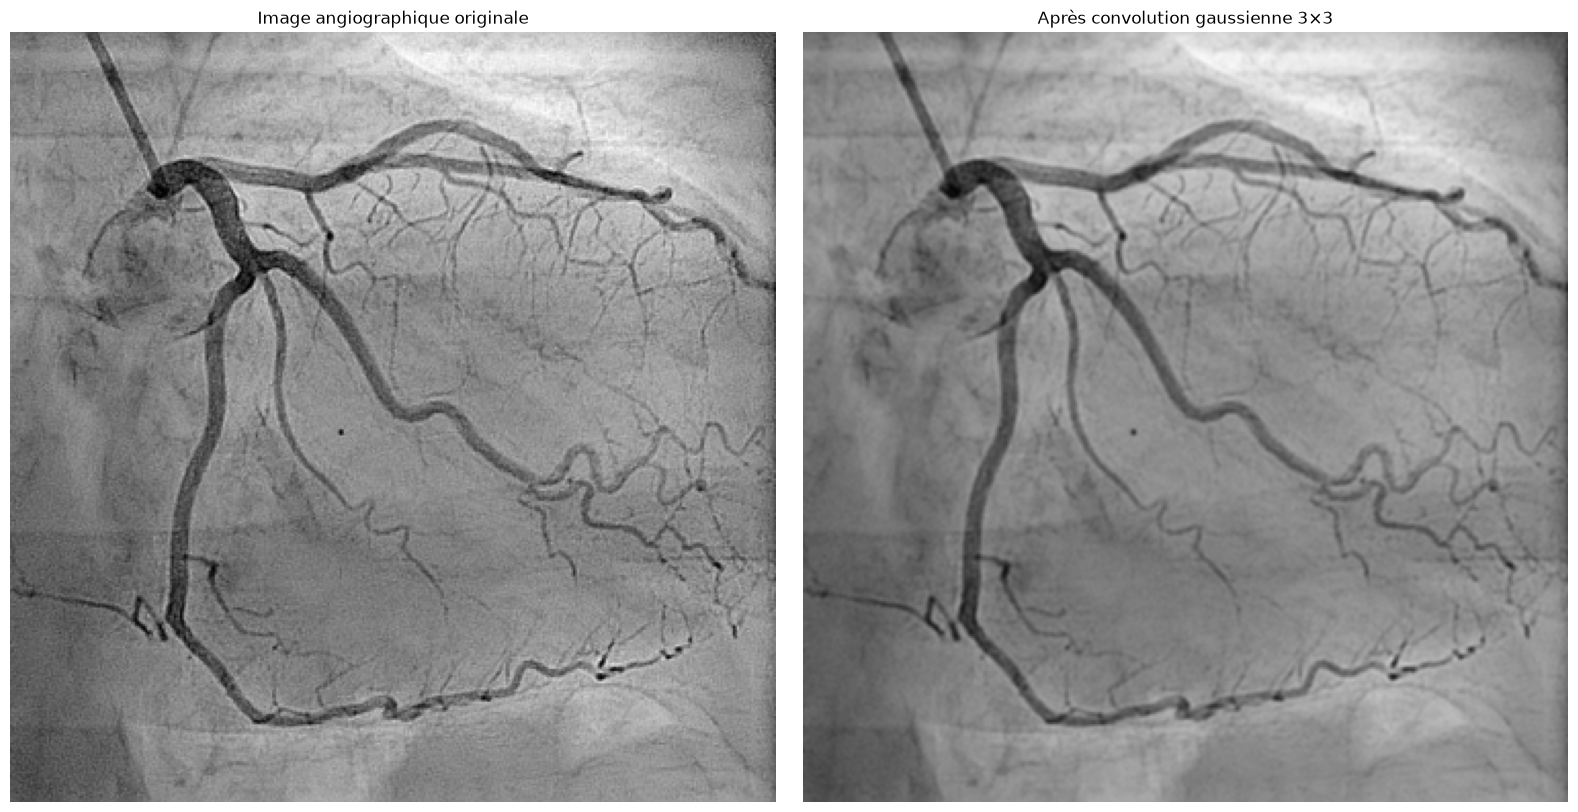

In [16]:
Wgaussienne3 = np.array([[1, 2, 1], [2, 4, 2], [1, 2, 1]]) / 16
img_gauss3 = convolve(img_angio, Wgaussienne3)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes[0].imshow(img_angio, cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Image angiographique originale')
axes[0].axis('off')
axes[1].imshow(img_gauss3, cmap='gray', vmin=0, vmax=1)
axes[1].set_title('Après convolution gaussienne 3×3')
axes[1].axis('off')

plt.tight_layout()
plt.show()

**7a.** Effectuez la même opération (convolution et affichage) avec une Gaussienne de taille 7x7: 

$W_{Gaussienne7}\ =\ \dfrac{1}{1115}\ 
\begin{bmatrix} 
 1 &  4 &  7 & 10 &  7 &  4 &  1 \\
 4 & 12 & 26 & 33 & 26 & 12 &  4 \\
 7 & 26 & 55 & 71 & 55 & 26 &  7 \\
10 & 33 & 71 & 91 & 71 & 33 & 10 \\
 7 & 26 & 55 & 71 & 55 & 26 &  7 \\
 4 & 12 & 26 & 33 & 26 & 12 &  4 \\
 1 &  4 &  7 & 10 &  7 &  4 &  1 \\
\end{bmatrix} $


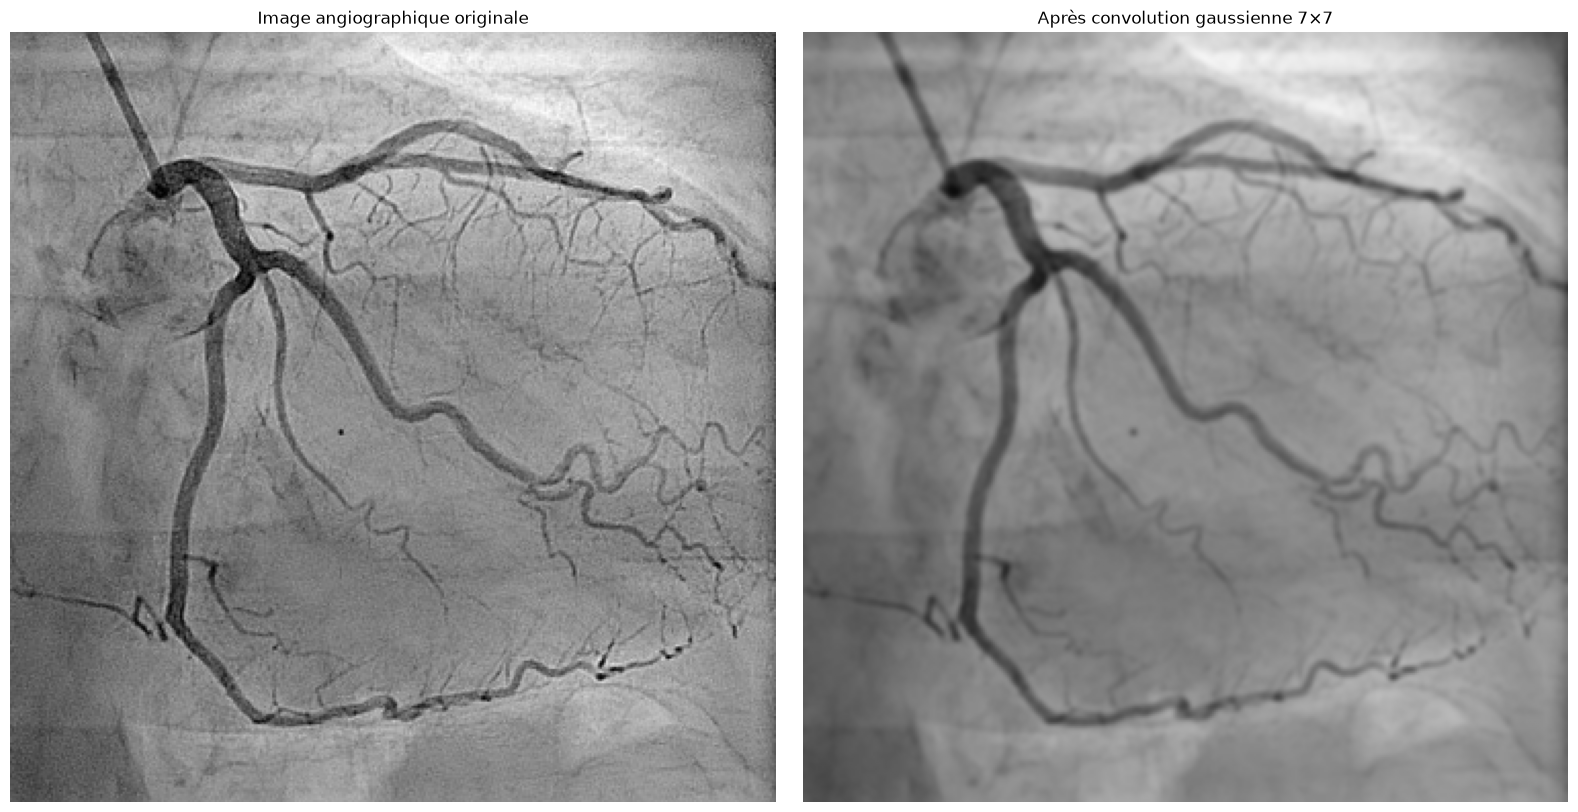

In [17]:
Wgaussienne7 = (
    np.array(
        [
            [1, 4, 7, 10, 7, 4, 1],
            [4, 12, 26, 33, 26, 12, 4],
            [7, 26, 55, 71, 55, 26, 7],
            [10, 33, 71, 91, 71, 33, 10],
            [7, 26, 55, 71, 55, 26, 7],
            [4, 12, 26, 33, 26, 12, 4],
            [1, 4, 7, 10, 7, 4, 1],
        ]
    )
    / 1115
)

img_gauss7 = convolve(img_angio, Wgaussienne7)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes[0].imshow(img_angio, cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Image angiographique originale')
axes[0].axis('off')
axes[1].imshow(img_gauss7, cmap='gray', vmin=0, vmax=1)
axes[1].set_title('Après convolution gaussienne 7×7')
axes[1].axis('off')

plt.tight_layout()
plt.show()

**7b.** Qu'observez vous lorsque l'écart-type de la gaussienne augmente ?  Quel est le type de ces deux filtres gaussiens?

In [ ]:
# Lorsque l'écart-type de la gaussienne augmente (de 3x3 à 7x7), le flou (lissage) de l'image est 
# plus prononcé. Les détails fins (hautes fréquences) sont plus atténués. L'image apparaît plus floue.
#
# Ces deux filtres gaussiens sont des filtres PASSE-BAS , puisqu'ils laissent passer les basses
# fréquences spatiales (les variations lentes d'intensité, les grandes structures) et
# diminueunt les hautes fréquences comme les détails fins, les contours et le bruit.
# Plus l'écart-type est grand, plus la fréquence de coupure est basse donc plus le lissage est fort.

**8a.** Calculez et affichez le Laplacien de l'image angiographique en la convoluant avec:

$W_{Laplacien}\ =\
\begin{bmatrix} 
 -1 & -1 & -1 \\
 -1 & 8 & -1 \\
 -1 & -1 & -1 \\
\end{bmatrix} $

_(Attention: le Laplacien d'une image contient des valeurs négatives, pour les visualiser correctement les bornes d'affichages doivent être -1 et 1!)_

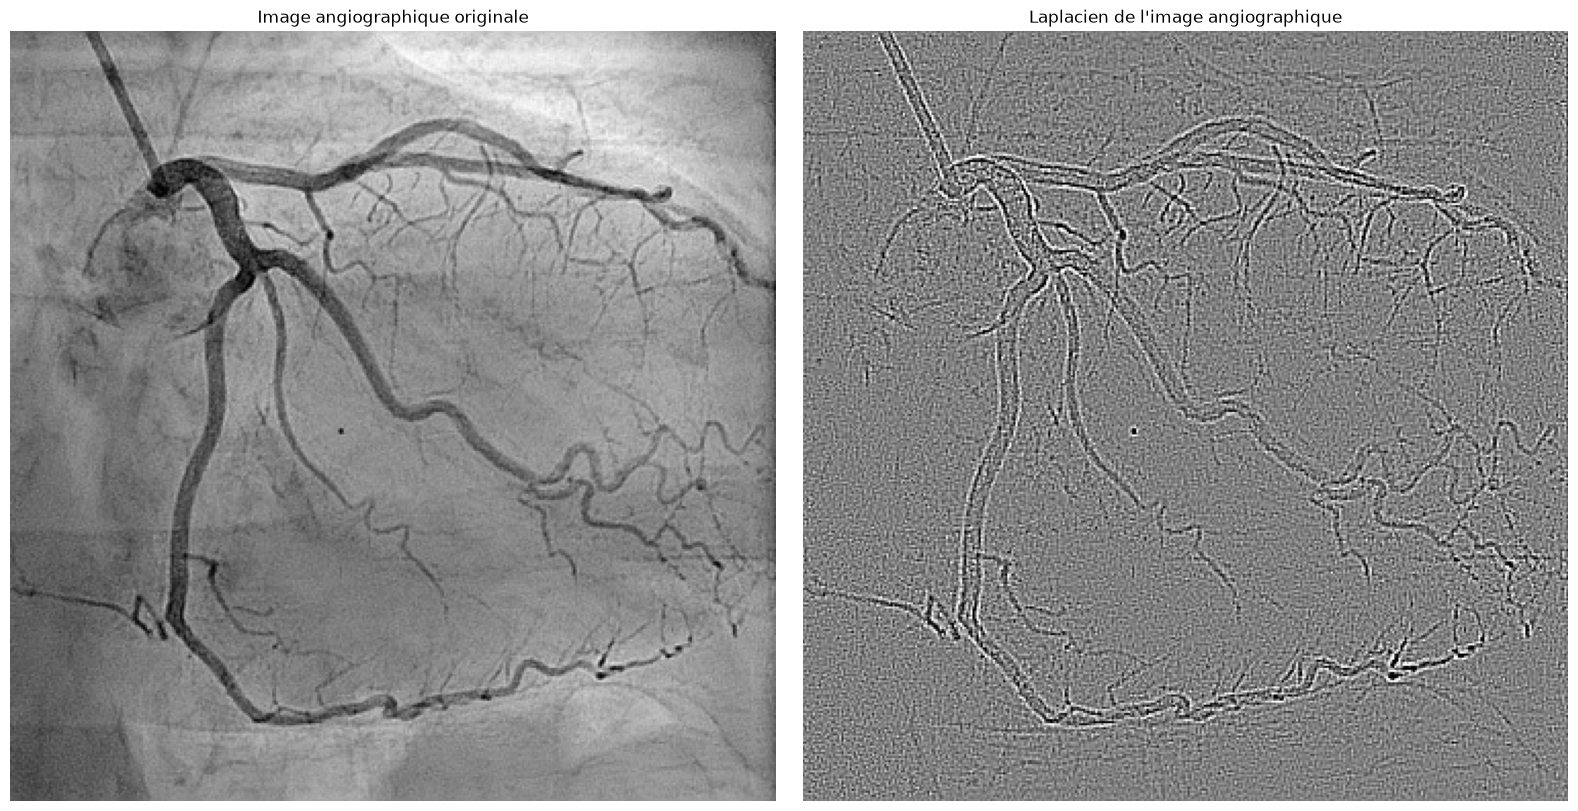

Laplacien - Min: -2.8902, Max: 2.5137


In [18]:
Wlaplacien = np.array([
[-1, -1, -1], 
[-1, 8, -1], 
[-1, -1, -1]])

img_laplacien = convolve(img_angio, Wlaplacien)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes[0].imshow(img_angio, cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Image angiographique originale')
axes[0].axis('off')
axes[1].imshow(img_laplacien, cmap='gray', vmin=-1, vmax=1)
axes[1].set_title('Laplacien de l\'image angiographique')
axes[1].axis('off')

plt.tight_layout()
plt.show()
print(f'Laplacien - Min: {img_laplacien.min():.4f}, Max: {img_laplacien.max():.4f}')

**8b.** Quel est le type de ce filtre?

In [ ]:
# Le filtre Laplacien est l'inverse, c'est un filtre PASSE-HAUT. 
# Il aide à voir les contours et les détails fins de l'image (les transitions rapides d'intensité),
# c'est-à-dire les hautes fréquences spatiales.

# On peut voir que le Laplacien fait ressortir les vaisseaux sanguins et les contours
# des structures, tandis que les régions homogènes sont proches de zéro.
# Le Laplacien est un opérateur de dérivée seconde, il détecte les variations rapides d'intensité 
# dans toutes les directions.

On rappelle que le filtrage high-boost est défini par:  
  $I_{g} =  I * W_{gaussienne3}$  
  $I_{HighBoost} = I + k \times (I_g * W_{laplacien})$  
  (avec $I$ l'image originale, $I_{HighBoost}$ l'image filtrée, et $I* _{gaussienne3}$ la convolution entre l'image et le masque gaussien de taille $3 \times 3$.)

**9a.** Implémentez la fonction `high_boost(img, k)` qui prend en paramètre l'image $I$ et $k$ et renvoie l'image après le filtrage High Boost. Affichez le résultat pour $k=0$, $k=1$ et $k=2$.  (Limitez l'affichage entre 0 et 1!)


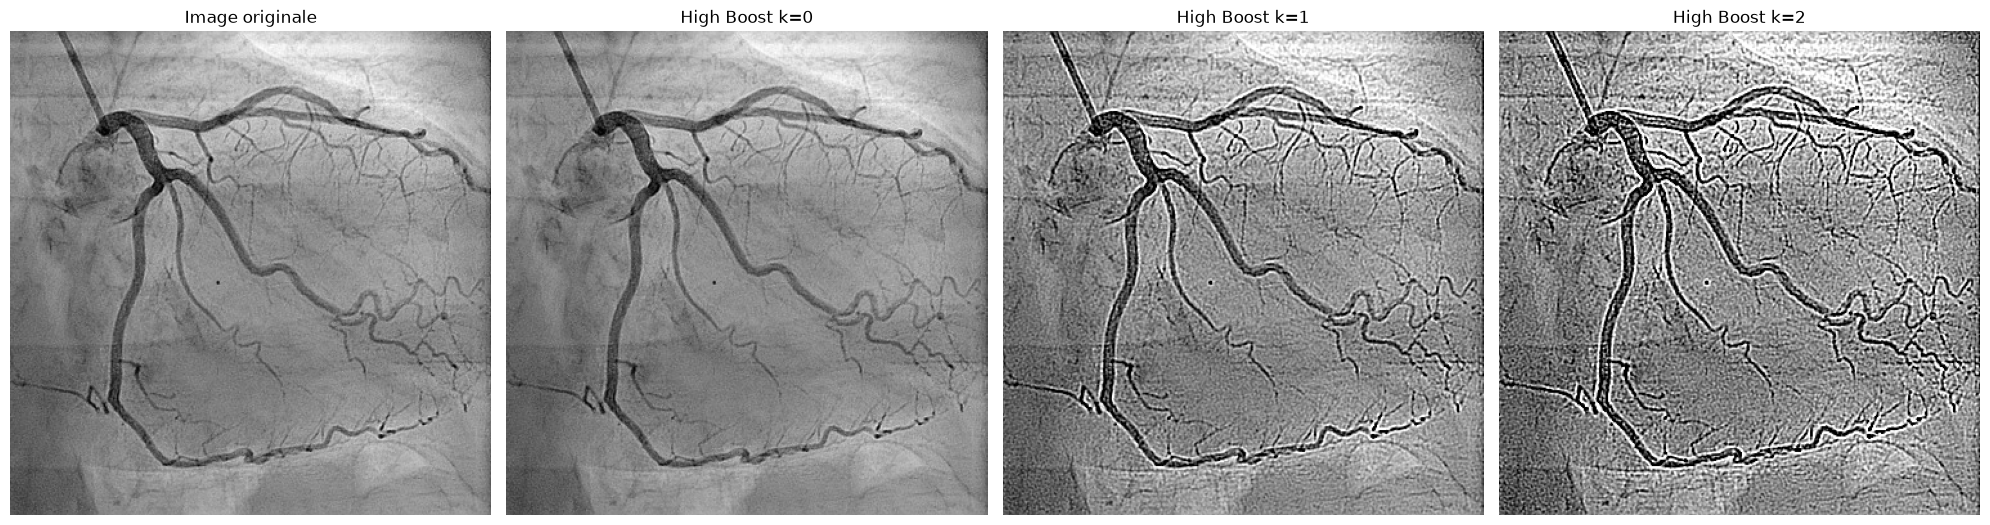

In [19]:
def high_boost(img, k):
    # appliquer le gaussien, le laplacien et le filtrage high boost
    I_g = convolve(img, Wgaussienne3)
    laplacien_Ig = convolve(I_g, Wlaplacien)
    I_hb = img + k * laplacien_Ig
    return I_hb

# affichage pour k = 0, 1, 2
k_values = [0, 1, 2]
fig, axes = plt.subplots(1, len(k_values) + 1, figsize=(20, 6))

axes[0].imshow(img_angio, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Image originale")
axes[0].axis("off")

for i, k in enumerate(k_values):
    img_hb = high_boost(img_angio, k)
    axes[i + 1].imshow(img_hb, cmap="gray", vmin=0, vmax=1)
    axes[i + 1].set_title(f"High Boost k={k}")
    axes[i + 1].axis("off")

plt.tight_layout()
plt.show()

**9b.** Discutez de l'impact du facteur $k$ sur la lisibilité de l'image (et donc la qualité du réhaussement).

In [ ]:
# si k = 0 : L'image High Boost est identique à l'image originale (aucun rehaussement)
# puisque I_HighBoost = I + 0 * (...) = I
#
# si k = 1 : Un rehaussement modéré est appliqué. Les contours et les détails fins
# (vaisseaux sanguins) sont mieux visibles, tout en conservant une bonne lisibilité
# globale de l'image. C'est un bon compromis entre rehaussement et qualité visuelle.
#
# si k = 2 : Le rehaussement est plus fort. Les contours sont encore plus marqués,
# mais le bruit est aussi amplifié. L'image est moins naturelle et certaines zones
# commencent à saturer (ça clip à 0 ou 1 à cause au vmin/vmax).
#
# Si on continue d'augmenter k les contours sont encore PLUS marqués et
# la lisibilité devient de pire en pire.

**9c.** Dans ce filtrage, pourquoi calculer le laplacien sur $I_g$ plutôt que sur $I$ directement?  
_(Appuyez-vous sur vos observations de la question 7b.)_

In [ ]:
# Le Laplacien est un opérateur de dérivée seconde, ce qui le rend
# extrêmement sensible au bruit présent dans l'image.
#
# On peut voir à la question 7b que filtre gaussien est un filtre passe-bas qui diminue 
# les hautes fréquences (bruit, petites variations aléatoires) tout en conservant les 
# structures importantes de l'image.
#
# En mettant d'abord le lissage gaussien (I_g = I * W_gaussienne3), on élimine une partie du bruit 
# haute fréquence. Le Laplacien appliqué ensuite sur I_g détecte alors les vrais contours et 
# détails structurels sans amplifier le bruit.
#
# Si on appliquait le Laplacien directement sur I, le bruit serait fortement amplifié par 
# la dérivée seconde, ce qui donnerait un rehaussement bruité et de mauvaise qualité.
#
# C'est le principe du filtre Laplacien de Gaussienne (LoG) : lisser pour débruiter, 
# puis détecter les contours.

# Exercice IV: Filtrage Médian et Morphologique

Cet exercice met en oeuvre des filtrages médians et morphologiques qui sont implémentés dans les modules pythons:   
```skimage.morphology``` et ```skimage.filters``` importé sous les noms: ```skmorph``` et ```skfilters``` (déjà importés dans la première cellule du notebook).

## Élimination du bruit par filtrage médian

**1a.** Chargez (sans conversion en intensités entières) et affichez l'image ```fundus_bruit.png```.

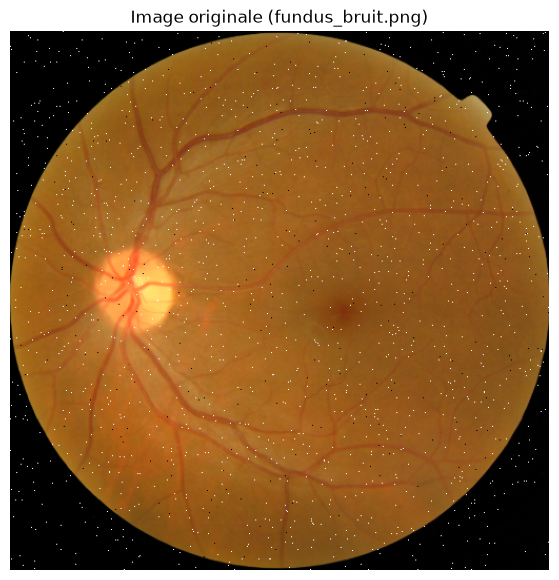

In [20]:
fundus = imread(os.path.join('fichiers_seance_2', 'fundus_bruit.png'))

plt.imshow(fundus)
plt.title("Image originale (fundus_bruit.png)")
plt.axis('off')
plt.show()

**1b.** Quel est le nom du bruit qui déteriore cette image de la rétine?

In [ ]:
# Bruit poivre et sel (bruit impulsionnel)

Pour la suite de l'exercice nous ne nous intéresserons qu'au canal vert de l'image.

**2.** Filtrez le bruit identifié à la question précédente à l'aide d'un filtrage médian [skfilters.median](https://scikit-image.org/docs/dev/api/skimage.filters.html#skimage.filters.median). Utilisez un élément structurant sous forme d'un disque (voir [skmorph.disk](https://scikit-image.org/docs/dev/api/skimage.morphology.html#skimage.morphology.disk)). Trouvez un rayon de disque approprié pour le filtrage. Affichez côte à côte le canal vert de l'image avant et après le filtrage.

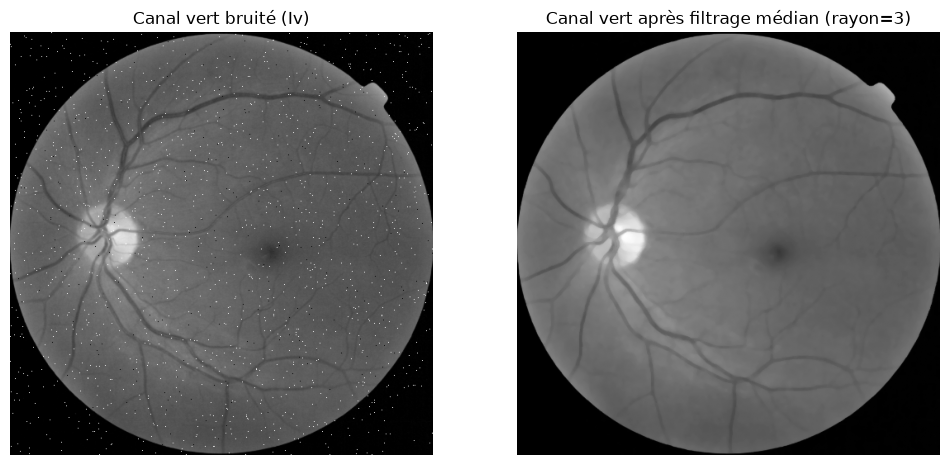

In [21]:
# On garde seulement le vert
Iv = fundus[:, :, 1]

rayon = 3  
elem_struct = skmorph.disk(rayon)
Iv_filtree = skfilters.median(Iv, elem_struct)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(Iv, cmap='gray')
axes[0].set_title("Canal vert bruité (Iv)")
axes[0].axis('off')
axes[1].imshow(Iv_filtree, cmap='gray')
axes[1].set_title(f"Canal vert après filtrage médian (rayon={rayon})")
axes[1].axis('off')
plt.show()

**3.** Filtrez le bruit identifié à la question précédente avec les filtres gaussiens utilisés à l'exercice précédent (convolution de l'image avec un filtre gaussien). Le filtrage gaussien présenté dans l'exercice I aurait-il été un meilleur ou moins bon choix pour cette tâche ? Pourquoi ?

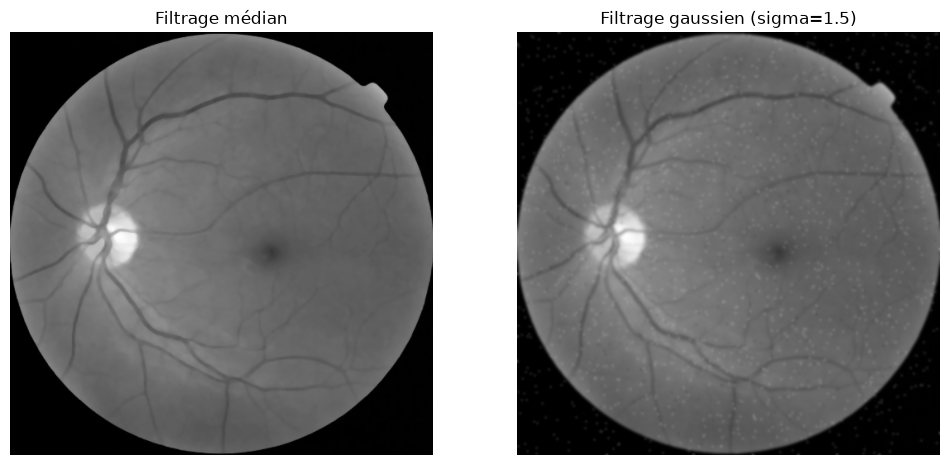

In [ ]:
# Filtre gaussien (sigma choisi par essai-erreur)
Iv_gauss = skfilters.gaussian(Iv, sigma=1.5)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(Iv_filtree, cmap='gray')
axes[0].set_title("Filtrage médian")
axes[0].axis('off')
axes[1].imshow(Iv_gauss, cmap='gray')
axes[1].set_title("Filtrage gaussien (sigma=1.5)")
axes[1].axis('off')
plt.show()

# Réponse : Le filtrage gaussien est un moins bon choix parce que c'est un filtre linéaire 
# passe-bas qui floute l'image entière. Par conséquent, il étale le bruit poivre et sel 
# plutôt que de l'enlever, et il vient également adoucir (flouter) les contours des vaisseaux 
# sanguins. 
# 
# Le filtre médian (non linéaire) est à l'inverse spécialement adapté pour éliminer le bruit 
# impulsionnel tout en préservant très bien la netteté des contours

Les traitements présentés dans les deux sections suivantes seront appliqués sur **la version filtrée du canal vert** de l'image notée $I_V$.

## Réhaussement des vaisseaux

Afin de simplifier la détection des vaisseaux sur les images de la rétine, un prétraitement très utilisé consiste à effectuer une correction d'illumination locale. En définissant $F_{m}$ un filtre médian avec un large élément structurant (un disque de rayon 12), l'image prétraitée $I_P$ est calculée par: $I_P = I_V - F_m(I_V)$.

**4a.** Calculez et affichez le résultat du filtrage médian $F_{m}(I_V)$ et du prétraitement $I_P$. Cette correction d'illumination est-elle efficace?


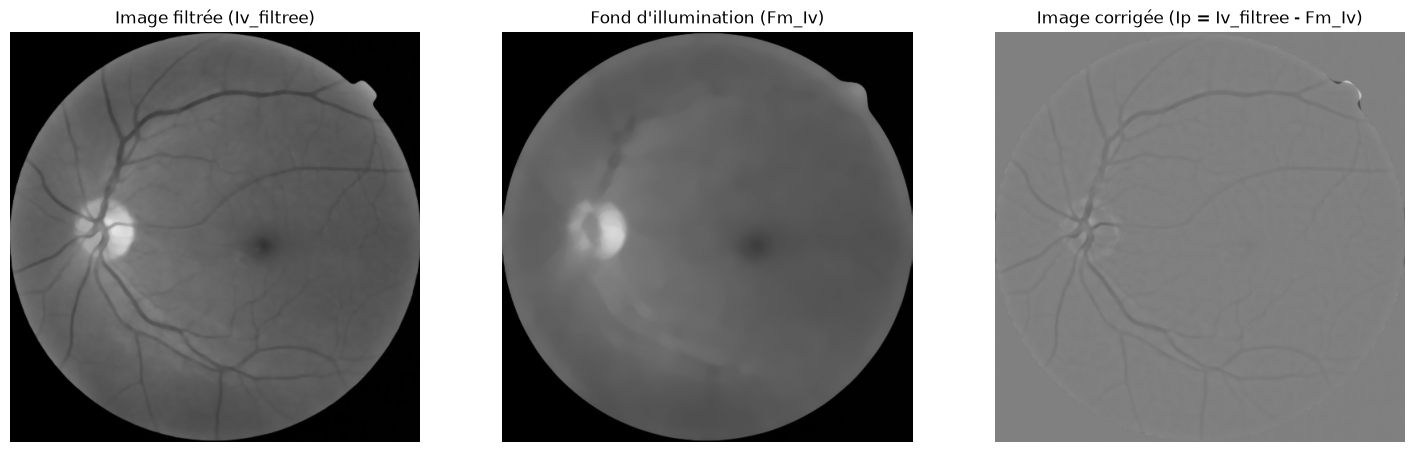

In [ ]:
# filtrage médian avec un grand rayon pour estimer l'illumination du fond
Fm_Iv = skfilters.median(Iv_filtree, skmorph.disk(12))

# Correction d'illumination (prétraitement)
Ip = Iv_filtree - Fm_Iv

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(Iv_filtree, cmap='gray', vmin=0, vmax=1)
axes[0].set_title("Image filtrée (Iv_filtree)")
axes[0].axis('off')
axes[1].imshow(Fm_Iv, cmap='gray', vmin=0, vmax=1)
axes[1].set_title("Fond d'illumination (Fm_Iv)")
axes[1].axis('off')
axes[2].imshow(Ip, cmap='gray', vmin=-1, vmax=1)
axes[2].set_title("Image corrigée (Ip = Iv_filtree - Fm_Iv)")
axes[2].axis('off')
plt.show()

# Oui, la correction d'illumination est très efficace. Elle permet de supprimer les variations 
# lentes de l'éclairage de fond. Ainsi, l'intensité du fond est aplanie, 
# et les structures comme les vaisseaux ressortent avec plus de contraste uniforme sur 
# toute l'image.

**4b.** Les vaisseaux sont-ils un contenu hautes ou basses fréquences spatiales? Même question pour le résultat du filtrage médian $F_{m}(I_V)$.

In [ ]:
# Les vaisseaux, sont un contenu de hautes fréquences spatiales à cause de leurs petits diamètres 
# et leurs bords très pointus. 
# À l'inverse, le résultat du filtrage médian avec le large disque Fm(Iv) capte uniquement 
# les variations douces et l'éclairage de fond, ce qui est les basses fréquences spatiales.

## Segmentation du disque optique

On se propose de segmenter le disque optique (la tête du nerf optique apparaissant en clair sur l'image et dont émerge les vaisseaux) avec un seuil et des opérations morphologiqes.

**5a.** Implémentez la fonction ```binariser(img, seuil)``` qui prend en paramètre une image et un seuil et qui renvoie l'image binarisée: où tous les pixels inférieurs au seuil valent $0$ et tous ceux égaux ou supérieurs au seuil valent $1$.

**5b.** Calculez et affichez l'image $I_V$ binarisée avec un seuil de $0.6$. On notera cette image binarisé $I_B$.

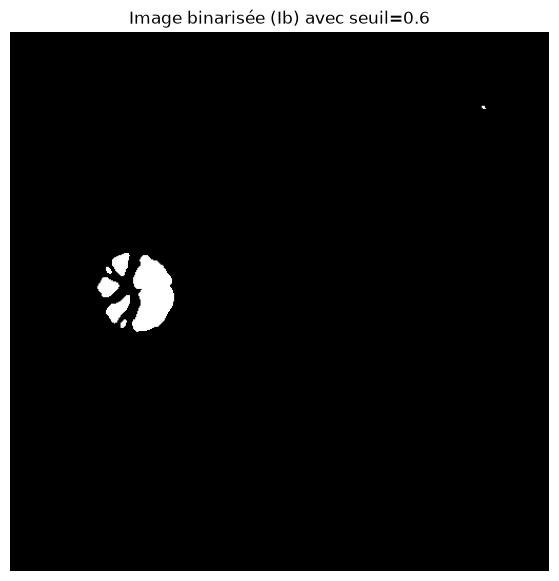

In [24]:
def binariser(img, seuil):
    return (img >= seuil).astype(int)

Ib = binariser(Iv_filtree, 0.6)

plt.imshow(Ib, cmap='gray')
plt.title("Image binarisée (Ib) avec seuil=0.6")
plt.axis('off')
plt.show()

Vous devriez constater deux erreurs:
 - les vaisseaux émergeant du disque optique forment des trous dans sa segmentation; 
 - un artefact est détecté à tord dans le coin supérieur droit de l'image. 
 
On va corriger ces deux erreurs avec une ouverture et une fermeture (cf. [skmorph.binary_opening](https://scikit-image.org/docs/dev/api/skimage.morphology.html#skimage.morphology.binary_opening) et [skmorph.binary_closing](https://scikit-image.org/docs/dev/api/skimage.morphology.html#skimage.morphology.binary_closing))

**6a.** Refermez les trous causés par les vaisseaux à l'aide de l'opération morphologique adéquate. Vous devrez choisir un élément structurant adapté. 

**6b.** Effacez l'artefact supérieur droit sans altérer la segmentation du disque avec l'autre opération morphlogique. Une fois encore, choisissez un élément structurant adapté.

/var/folders/39/_54p0zcx5wvb8h22bj1f3_4c0000gn/T/ipykernel_21353/4114203692.py:1: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  Ib_fermee = skmorph.binary_closing(Ib, skmorph.disk(12))
/var/folders/39/_54p0zcx5wvb8h22bj1f3_4c0000gn/T/ipykernel_21353/4114203692.py:2: FutureWarning: `binary_opening` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.opening` instead.
  Ib_finale = skmorph.binary_opening(Ib_fermee, skmorph.disk(10))


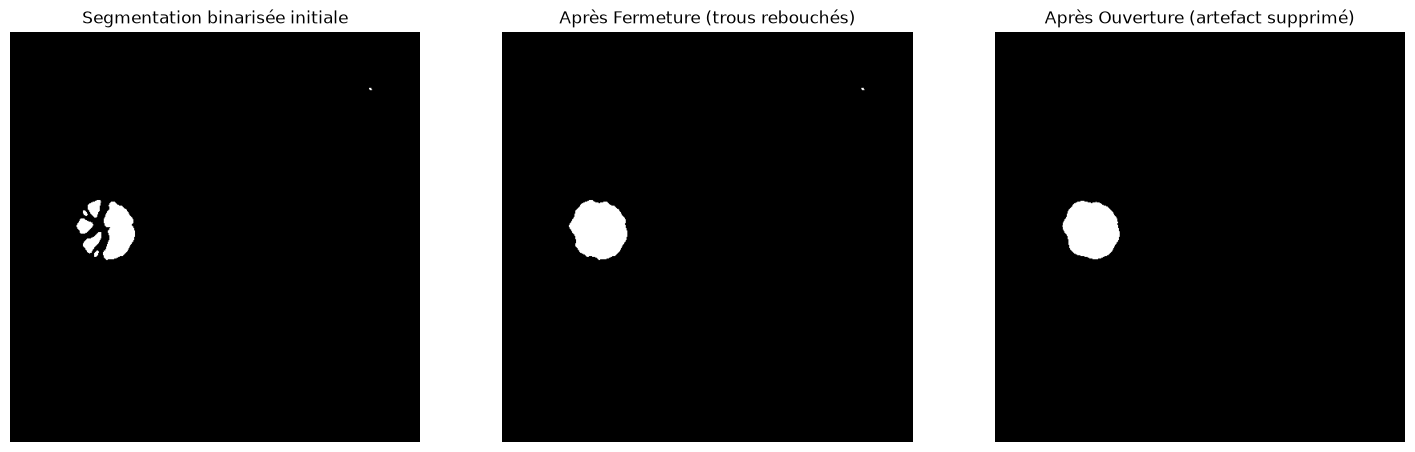

In [25]:
Ib_fermee = skmorph.binary_closing(Ib, skmorph.disk(12)) 
Ib_finale = skmorph.binary_opening(Ib_fermee, skmorph.disk(10)) 

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(Ib, cmap='gray')
axes[0].set_title("Segmentation binarisée initiale")
axes[0].axis('off')
axes[1].imshow(Ib_fermee, cmap='gray')
axes[1].set_title("Après Fermeture (trous rebouchés)")
axes[1].axis('off')
axes[2].imshow(Ib_finale, cmap='gray')
axes[2].set_title("Après Ouverture (artefact supprimé)")
axes[2].axis('off')
plt.show()

On souhaite faire une estimation rapide du rayon et du centre du disque optique tel qu'il a été segmenté aux questions précédentes.

**7.** En effectuant des érosions successives de la segmentation par des disques de rayon 1,2,3... jusqu'à ce que la segmentation disparaisse, déterminez le rayon et la position du centre du disque optique.


In [26]:
segmentation = Ib_finale.copy()
rayon_estime = 0
centre_y, centre_x = 0, 0

while np.any(segmentation):
    y, x = np.where(segmentation)
    if len(y) > 0:
        centre_y = int(np.mean(y))
        centre_x = int(np.mean(x))
    # érosion avec un rayon de 1
    segmentation = skmorph.binary_erosion(segmentation, skmorph.disk(1))
    rayon_estime += 1

print(f"Rayon estimé : {rayon_estime} pixels")
print(f"Position du centre estimé : (y = {centre_y}, x = {centre_x})")

Rayon estimé : 35 pixels
Position du centre estimé : (y = 248, x = 120)


/var/folders/39/_54p0zcx5wvb8h22bj1f3_4c0000gn/T/ipykernel_21353/601986174.py:11: FutureWarning: `binary_erosion` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.erosion` instead. Note the pixel shift by 1 for even-sized footprints (see docstring notes).
  segmentation = skmorph.binary_erosion(segmentation, skmorph.disk(1))


# Exercice V: Extraction d'un marqueur clinique depuis des images OCT


**1.** Ouvrez et affichez l'image ```RET002OD.jpg```, se trouvant dans le sous-dossier ```exercice_v```. 

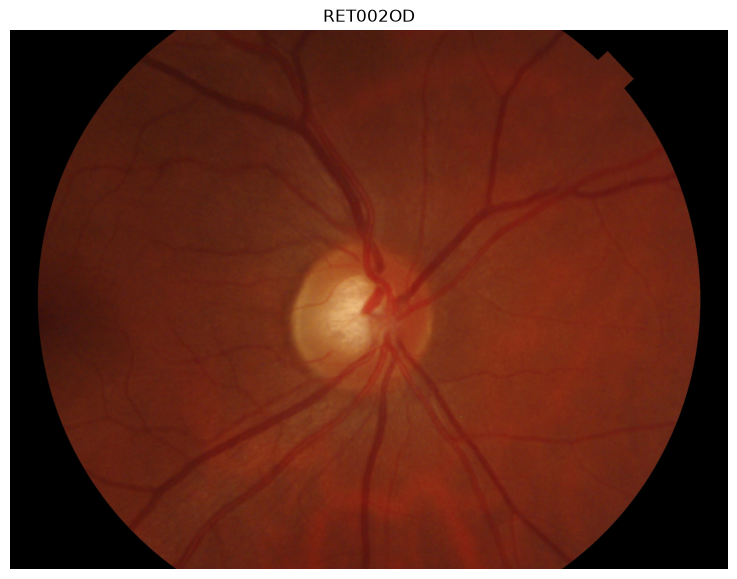

In [27]:
# Vous pouvez définir dans une variable les noms des dossiers où se trouvent vos images, les contours, etc.,
# cela pourra rendre votre code plus lisible par la suite.
import matplotlib.pyplot as plt
import numpy as np
from skimage.io import imread
import os

dossier_exercice_v = os.path.join("fichiers_seance_2", "exercice_v")
img_path = os.path.join(dossier_exercice_v, "RET002OD.jpg")
img = imread(img_path)
plt.imshow(img, cmap='gray')
plt.title("RET002OD")
plt.axis('off')
plt.show()


**2.** Chargez les contours de l'image ```RET0020OD.jpg```. Les contours se trouvent dans le sous-dossier ```Contours``` et ont des noms similaires à ceux des images associées. Affichez les masques dans la même figure, côte à côte.

In [30]:
# Cette fonction permet de convertir un vecteur de points en polygone.
# Vous pouvez l'utiliser pour convertir le contour en masque binaire représentant la région d'intérêt.
def get_mask_from_contour(contour: np.ndarray, img: np.ndarray):
    mask = np.zeros(img.shape[:2], dtype=np.bool)
    rr, cc = drw.polygon(contour[:, 1], contour[:, 0])
    mask[rr, cc] = 1
    return mask

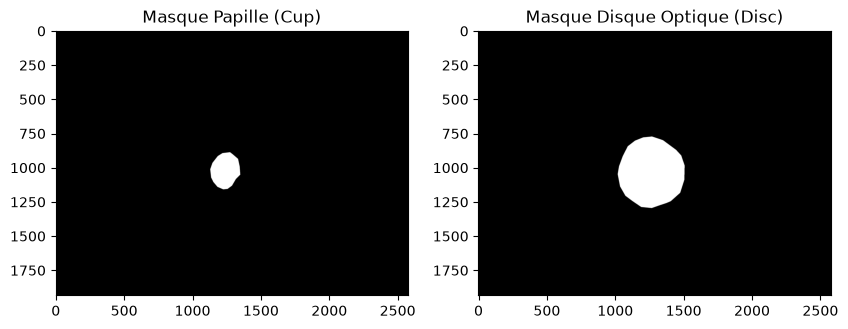

In [31]:
dossier_contours = os.path.join(dossier_exercice_v, "Contours")
contour_cup = np.loadtxt(os.path.join(dossier_contours, "RET002OD_cup.txt"))
contour_disc = np.loadtxt(os.path.join(dossier_contours, "RET002OD_disc.txt"))

mask_cup = get_mask_from_contour(contour_cup, img)
mask_disc = get_mask_from_contour(contour_disc, img)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(mask_cup, cmap='gray')
axes[0].set_title("Masque Papille (Cup)")
axes[1].imshow(mask_disc, cmap='gray')
axes[1].set_title("Masque Disque Optique (Disc)")
plt.show()


**3.** Calculez la largeur et la hauteur de la papille et du disque optique et calculez le ratio papille / disque optique ("cup to disc ratio") selon les deux directions.

In [ ]:
cup_height = np.max(contour_cup[:, 0]) - np.min(contour_cup[:, 0])
cup_width = np.max(contour_cup[:, 1]) - np.min(contour_cup[:, 1])
disc_height = np.max(contour_disc[:, 0]) - np.min(contour_disc[:, 0])
disc_width = np.max(contour_disc[:, 1]) - np.min(contour_disc[:, 1])

ratio_vertical = cup_height / disc_height
ratio_horizontal = cup_width / disc_width

print(f"Largeur papille: {cup_width:.2f},  Hauteur: {cup_height:.2f}")
print(f"Largeur disque: {disc_width:.2f}, Hauteur: {disc_height:.2f}")
print(f"Ratio vertical:  {ratio_vertical:.3f}")
print(f"Ratio horizontal: {ratio_horizontal:.3f}") 


Largeur papille: 272.00,  Hauteur: 219.98
Largeur disque: 523.40, Hauteur: 489.81
Ratio vertical:  0.449
Ratio horizontal: 0.520


<span style='color: green;'>
    
On se concentrera principalement sur le contour de la papille pour les prochaines questions.

</span>

**4.** À partir des points du contour de la papille, créez une matrice de distance qui contient la distance euclédienne entre chaque paire de points du contour de la papille.

In [35]:
# Plutôt que d'y aller avec une approche qui itère sur tous les pixels du contour, vous pouvez utiliser les propriétés
# de broadcasting des arrays numpy.
# La syntaxe mon_array[None, :, :] vient ajouter une dimension (vide) dans le premier axe.
# La syntaxe mon_array[:, None, :] vient ajouter une dimension (vide) dans le deuxième axe.
# Par défaut, une addition ou une soustraction de deux arrays de tailles compatibles (1, n, d) et (m, 1, d) créera une
# matrice de taille (m, n, d).
# La fonction np.linalg.norm pourrait être utile également.
matrice_distance_cup = np.linalg.norm(contour_cup[:, None, :] - contour_cup[None, :, :], axis=2)


**5.** (Bonus) Comment pourriez-vous valider que votre matrice de distance correspond bien à ce à quoi vous vous attendez? Vous pouvez regarder sa forme, sa structure, etc.

In [36]:
print(f"Forme de la matrice: {matrice_distance_cup.shape}")
print(f"Symétrique ? {np.allclose(matrice_distance_cup, matrice_distance_cup.T)}")
print(f"Diagonale nulle ? {np.allclose(np.diag(matrice_distance_cup), 0)}")


Forme de la matrice: (16, 16)
Symétrique ? True
Diagonale nulle ? True


**6.** Affichez la matrice de distance finale. Indiquez dans le titre du graphe la distance maximale. 

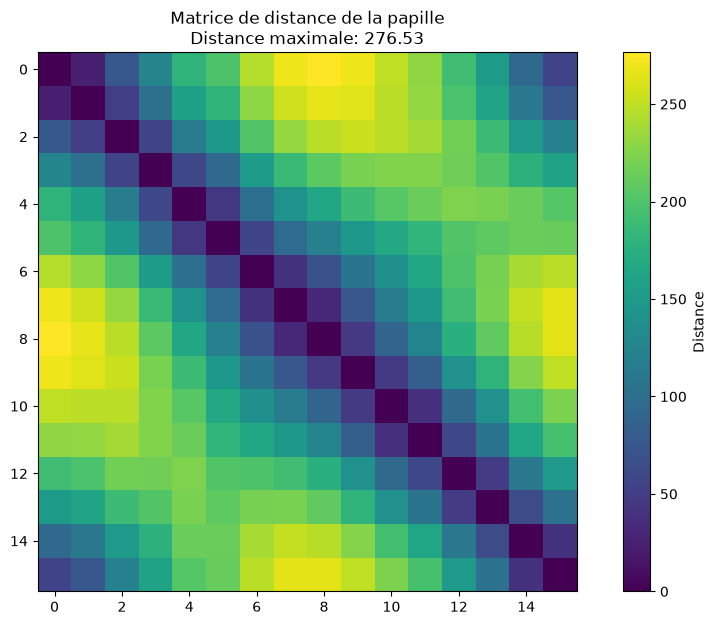

In [37]:
max_dist = np.max(matrice_distance_cup)
plt.imshow(matrice_distance_cup, cmap='viridis')
plt.colorbar(label="Distance")
plt.title(f"Matrice de distance de la papille\nDistance maximale: {max_dist:.2f}")
plt.show()


<span style='color: red;'>

Attention, on s'intéresse de nouveau aux deux contours, la papille et le disque optique, pour les questions suivantes.

</span>

### Application du marqueur sur des cohortes de patients

**7.** Chargez le fichier excel ```patient_data.xlsx``` et affichez son contenu. Extrayez les index correspondant aux sujets sains (diagnostic = 0), aux sujets atteints de glaucome (diagnostic = 1), et les sujets suspects (diagnostic = 2). Gardez les index de vos trois cohortes dans trois listes distinctes.

In [38]:
# Vous pouvez utiliser la fonction pd.read_excel (du package pandas)
# On accède à une colonne d'une table pandas avec la syntaxe table['NomColonne']

path_fichier_excel = os.path.join("fichiers_seance_2", "exercice_v", "patient_data.xlsx")
table = pd.read_excel(path_fichier_excel, header=1, sheet_name="GBM8770")
table

,ID,Age,Gender,Diagnosis,dioptre_1,dioptre_2,astigmatism,Phakic/Pseudophakic,Pneumatic,Perkins,Pachymetry,Axial_Length,VF_MD
0,2,47,0,2,0.75,-1.75,90.0,0.0,21.0,NaN,586.0,23.64,-0.07
1,4,58,1,1,1.50,-1.75,85.0,0.0,NaN,19.0,501.0,23.06,-3.26
2,5,89,1,1,-0.75,-1.25,101.0,1.0,13.0,14.0,565.0,23.81,-14.98
3,6,69,0,2,1.00,-1.50,95.0,0.0,22.0,NaN,612.0,26.25,-2.07
4,7,22,1,2,-0.25,0.00,0.0,0.0,14.0,NaN,NaN,23.39,-2.30
...,...,...,...,...,...,...,...,...,...,...,...,...,...
239,289,64,0,0,0.50,-1.00,120.0,1.0,12.0,NaN,529.0,22.27,NaN
240,290,75,1,0,0.25,-0.25,5.0,1.0,14.0,NaN,577.0,22.00,NaN
241,291,55,0,0,1.25,-1.25,92.0,0.0,12.0,NaN,452.0,23.53,NaN
242,292,56,1,0,1.75,-1.50,73.0,0.0,10.0,NaN,499.0,23.68,NaN


In [ ]:
idx_sains = table[table['Diagnosis'] == 0]['ID'].tolist()
idx_glaucome = table[table['Diagnosis'] == 1]['ID'].tolist()
idx_suspects = table[table['Diagnosis'] == 2]['ID'].tolist()

print(f"{len(idx_sains)} sujets sains")
print(f"{len(idx_glaucome)} sujets glaucomateux")
print(f"{len(idx_suspects)} sujets suspects")

170 sujets sains
40 sujets glaucomateux
34 sujets suspects


**8.** Encapsulez votre logique de calcul de diamètres maximaux dans une fonction. Cette fonction prend en entrée l'identifiant ("ID") de l'image à traiter, puis calcule le diamètre maximal mesuré entre toutes les paires de points pour la papille et le disque. Votre fonction retournera le diamètre maximal de la papille et le diamètre maximal du disque optique. Vous pouvez vous créer des fonctions intermédiaires pour simplifier le code si vous le désirez.

<span style='color: green;'>Les f-strings de Python peuvent vous être particulièrement utiles pour passer d'un identifiant numérique à une chaine de caractères. En particulier, prenez note du format des noms de fichiers de contour: `"RET002OD_cup.txt"` peut être généré avec `f"RET{identifiant:03d}OD_cup.txt"` pour `identifiant = 2`.
</span>

In [49]:
def calcule_diametres_id(id: int) -> tuple[float, float]:
    path_cup = os.path.join("fichiers_seance_2", "exercice_v", "Contours", f"RET{id:03d}OD_cup.txt")
    path_disc = os.path.join("fichiers_seance_2", "exercice_v", "Contours", f"RET{id:03d}OD_disc.txt")

    if not os.path.exists(path_cup) or not os.path.exists(path_disc):
        return np.nan, np.nan 

    c_cup = np.loadtxt(path_cup)
    c_disc = np.loadtxt(path_disc) 
    dist_cup = np.linalg.norm(c_cup[:, None, :] - c_cup[None, :, :], axis=2)
    dist_disc = np.linalg.norm(c_disc[:, None, :] - c_disc[None, :, :], axis=2)

    return np.max(dist_cup), np.max(dist_disc) 


**9.** Vérifiez que votre nouvelle fonction vous donne le même résultat qu'à la question 5 pour l'identifiant 2.

In [43]:
d_cup, d_disc = calcule_diametres_id(2)
print(f"Max papille: {d_cup:.2f} (Attendu: {max_dist:.2f})")
print(f"Max disque: {d_disc:.2f}")


Max papille: 276.53 (Attendu: 276.53)
Max disque: 523.41


**10.** Pour chaque sujet dans vos listes, calculez le diamètre maximal de la papille et du disque optique, puis calculez le ratio papille / disque optique (_cup to disc ratio_). Sauvegardez les valeurs dans une liste pour un affichage ultérieur. 

In [44]:
ratios_sains = []
for id_ in idx_sains:
    c, d = calcule_diametres_id(id_)
    if not np.isnan(c) and not np.isnan(d) and d != 0:
        ratios_sains.append(c / d)

ratios_glaucome = []
for id_ in idx_glaucome:
    c, d = calcule_diametres_id(id_)
    if not np.isnan(c) and not np.isnan(d) and d != 0:
        ratios_glaucome.append(c / d)

ratios_suspects = []
for id_ in idx_suspects:
    c, d = calcule_diametres_id(id_)
    if not np.isnan(c) and not np.isnan(d) and d != 0:
        ratios_suspects.append(c / d)


**11.** Affichez sous la forme d'un box plot les valeurs trouvées pour vos trois cohortes. Vous devriez remarquer qu'une cohorte possède un ratio très différent des autres. Laquelle est-ce ? Est-ce attendu ? Que pouvez-vous conclure sur les sujets indiqués ```suspects``` ?

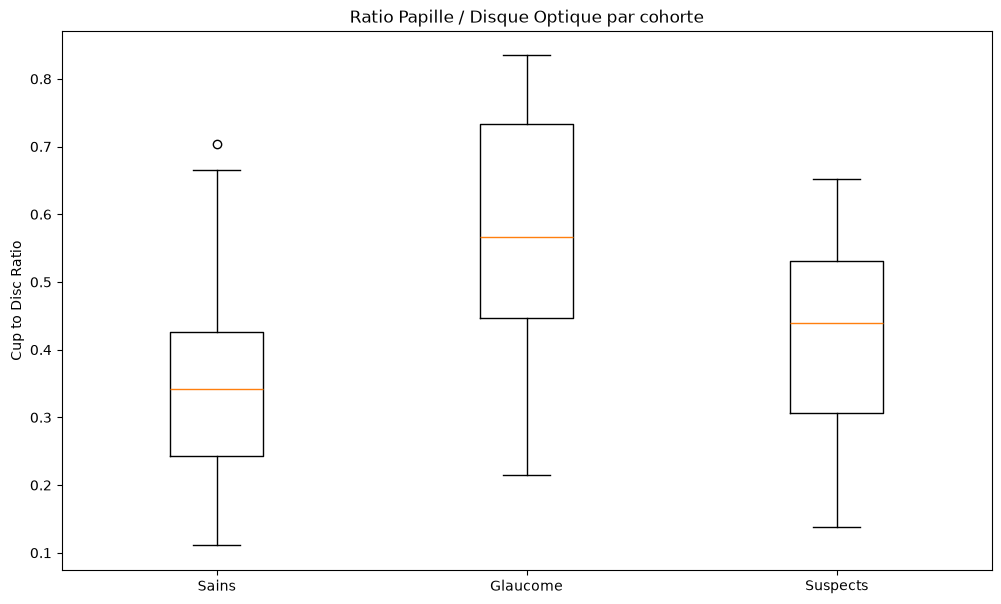

In [ ]:
plt.boxplot([ratios_sains, ratios_glaucome, ratios_suspects], tick_labels=['Sains', 'Glaucome', 'Suspects'])
plt.title("Ratio Papille / Disque Optique par cohorte")
plt.ylabel("Cup to Disc Ratio")
plt.show()

# La cohorte glaucome a un ratio beaucoup plus élevé. C'est normal 
# car le glaucome agrandit la papille (excavation glaucômateuse).
# Les suspects ont des valeurs intermédiaires ou très variables.


**12.** (Bonus) Comment pourriez-vous démontrer que les différences entre les différents groupes sont significatives? Implémentez votre idée et commentez sur vos résultats.

In [48]:
from scipy import stats

# Test Sains vs Glaucome
t_stat, p_val = stats.ttest_ind(ratios_sains, ratios_glaucome, equal_var=False)
print(f"T-test (Sains vs Glaucome) - p-value: {p_val:.2e}")
if p_val < 0.05:
    print("La différence est statistiquement significative entre Sains et Glaucome.")
else:
    print("La différence n'est pas significative.")


T-test (Sains vs Glaucome) - p-value: 1.10e-10
La différence est statistiquement significative entre Sains et Glaucome.


In [ ]:
# Analyse :
#
# Avec une p-value de 1,10 × 10⁻¹⁰, 
# bien en dessous du seuil habituel de 0,05, on peut rejeter 
# l'hypothèse nulle en toute confiance. Les deux groupes présentent 
# donc des moyennes réellement différentes, et non un simple effet
# du hasard. Cela confirme ce que laissait déjà voir la boîte à
# moustaches, et cela correspond à ce que l'on sait en clinique :
# le glaucome s'accompagne d'une excavation de la papille 
# (rapport Cup/Disc) nettement plus marquée que chez les
# patients sains.